# Seminar 4 - Wi-Fi performance prediction with a Feedforward Neural Network

The goal of this seminar is to predict Wi-Fi performance from measurements collected in residential networks.  
Compared with the linear regression approach used before, here we use a small feedforward neural network (FNN), which can model non-linear relations between the inputs and the two performance metrics.

The notebook is divided into two parts:

1. **Data preparation and analysis**: basic statistics, distributions, correlations and useful observations.
2. **FNN predictor**: feature preparation, model design, training and evaluation on the test set.

The two predicted values are:

- `TxThroughput`: achieved throughput;
- `AvgPingLatency`: average ping latency.

In [1]:
# Basic libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# I fix the seeds so that the results are easier to reproduce.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# On some computers PyTorch can be slower if it uses too many CPU threads.
torch.set_num_threads(1)

plt.rcParams["figure.figsize"] = (8, 4)
pd.set_option("display.max_columns", 20)

## 1. Loading the data

The statement already provides a train/test split, so I keep it. The test set is only used at the end for the final evaluation.

In [2]:
# The notebook is expected to be launched from the Seminar 4 folder.
train_df = pd.read_csv("dataset/train_data.csv")
test_df = pd.read_csv("dataset/test_data.csv")

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

train_df.head()

Training set shape: (33600, 7)
Test set shape: (8400, 7)


,LocationNumber,RSSI,TxLinkSpeed,RxLinkSpeed,MainAPConnect,TxThroughput,AvgPingLatency
0,2,-72.32,163.11,118.36,1,13.51,51.79
1,32,-73.18,238.45,212.83,1,3.35,68.80
2,20,-40.67,865.44,863.39,1,17.62,50.79
3,10,-60.66,473.89,396.92,1,14.30,64.15
4,29,-67.96,479.74,355.99,1,4.81,73.81


In [3]:
features = ["LocationNumber", "RSSI", "TxLinkSpeed", "RxLinkSpeed", "MainAPConnect"]
targets = ["TxThroughput", "AvgPingLatency"]

print("Column types:")
display(train_df.dtypes)

print("Missing values in the training set:")
display(train_df.isna().sum())

print("Missing values in the test set:")
display(test_df.isna().sum())

Column types:


LocationNumber      int64
RSSI              float64
TxLinkSpeed       float64
RxLinkSpeed       float64
MainAPConnect       int64
TxThroughput      float64
AvgPingLatency    float64
dtype: object

Missing values in the training set:


LocationNumber    0
RSSI              0
TxLinkSpeed       0
RxLinkSpeed       0
MainAPConnect     0
TxThroughput      0
AvgPingLatency    0
dtype: int64

Missing values in the test set:


LocationNumber    0
RSSI              0
TxLinkSpeed       0
RxLinkSpeed       0
MainAPConnect     0
TxThroughput      0
AvgPingLatency    0
dtype: int64

The files are clean: all columns are numeric and there are no missing values in either the training set or the test set. So the work here is not really about cleaning the dataset, but more about preparing the variables correctly before giving them to the neural network.

## 2. Descriptive statistics

I first look at the scale of each variable. This is important because a neural network usually trains better when the numerical inputs are on comparable scales.

In [4]:
summary = train_df.describe().T
summary[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3)

,mean,std,min,25%,50%,75%,max
LocationNumber,18.151,10.338,1.00,9.000,18.000,27.000,36.00
RSSI,-62.364,9.442,-79.04,-70.360,-62.910,-53.790,-37.02
TxLinkSpeed,491.265,240.869,33.24,273.200,476.635,664.390,905.39
RxLinkSpeed,460.954,251.600,-12.53,249.128,396.480,656.422,911.00
MainAPConnect,0.914,0.280,0.00,1.000,1.000,1.000,1.00
TxThroughput,12.989,4.414,0.78,11.320,14.790,15.980,19.16
AvgPingLatency,54.771,8.736,39.30,48.940,52.290,57.470,96.55


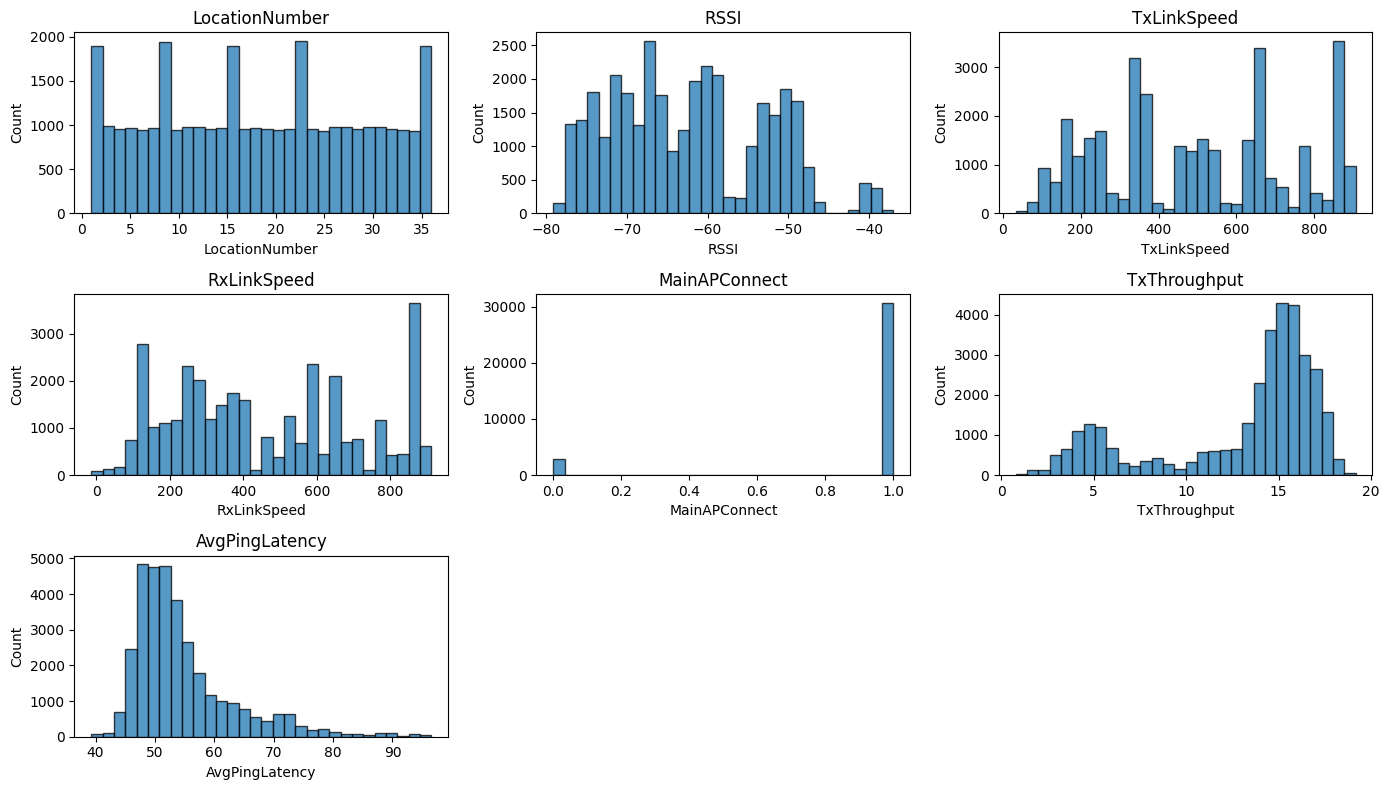

In [5]:
# Quick view of the distributions.
columns_to_plot = features + targets

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    axes[i].hist(train_df[col], bins=30, edgecolor="black", alpha=0.75)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the two empty axes.
for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

The first statistics and plots show a few important points:

- `RSSI`, `TxLinkSpeed` and `RxLinkSpeed` are on very different scales, so standardization is needed before training;
- most samples are connected to the main AP (`MainAPConnect = 1`), so the extender cases are less frequent;
- throughput is usually around 13 Mbps on average, but it still has a visible spread;
- latency is around 55 ms on average, with some high values going close to 100 ms.

This already explains why a neural network can be useful: the model has to combine location, signal quality and AP connection, instead of relying on a single variable.

## 3. Correlation analysis

The next step is to check which inputs are linearly related to throughput and latency. This does not fully describe the problem, but it gives a useful first intuition before using the FNN.

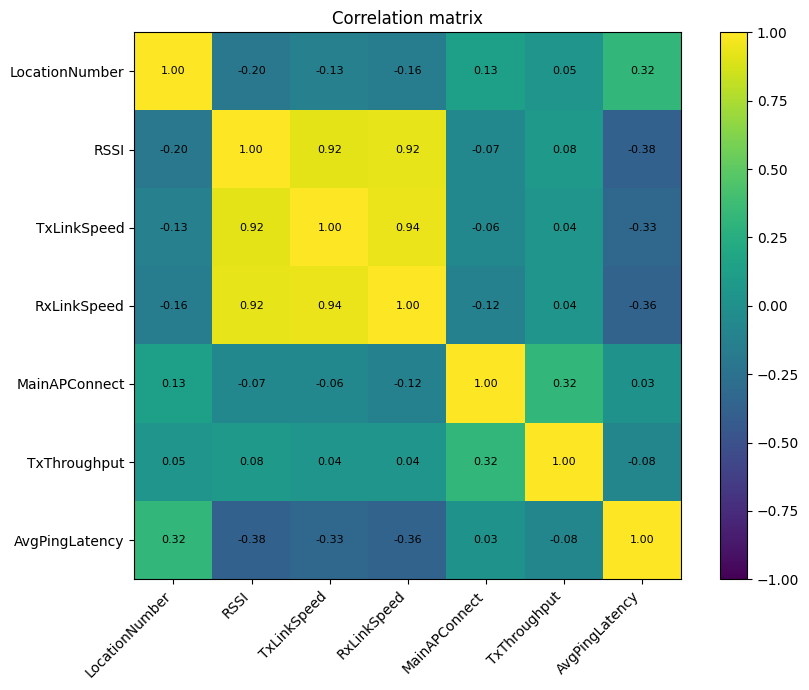

,TxThroughput,AvgPingLatency
LocationNumber,0.047,0.323
RSSI,0.077,-0.376
TxLinkSpeed,0.044,-0.331
RxLinkSpeed,0.044,-0.362
MainAPConnect,0.321,0.029
TxThroughput,1.000,-0.081
AvgPingLatency,-0.081,1.000


In [6]:
corr = train_df[features + targets].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

# Focus only on the two target variables.
corr[targets].round(3)

The correlation values are moderate, not extremely strong. That means the problem is not just “one feature directly gives the answer”.

The clearest points are:

- `MainAPConnect` is the most useful linear indicator for throughput, with a correlation around **0.32**;
- latency is more related to signal and link quality: `RSSI`, `TxLinkSpeed` and `RxLinkSpeed` have negative correlations with latency;
- throughput is less linearly related to `RSSI` or link speed, so it is probably affected by other conditions not included in the dataset.

So the FNN is a reasonable choice here, because it can combine several weak/moderate signals instead of only fitting one linear relation.

In [7]:
# Average values depending on the AP connection type.
by_ap = train_df.groupby("MainAPConnect")[["TxThroughput", "AvgPingLatency", "RSSI", "TxLinkSpeed", "RxLinkSpeed"]].mean()
by_ap.round(3)

,TxThroughput,AvgPingLatency,RSSI,TxLinkSpeed,RxLinkSpeed
MainAPConnect,,,,,
0,8.371,53.946,-60.350,541.534,563.005
1,13.424,54.849,-62.554,486.532,451.347


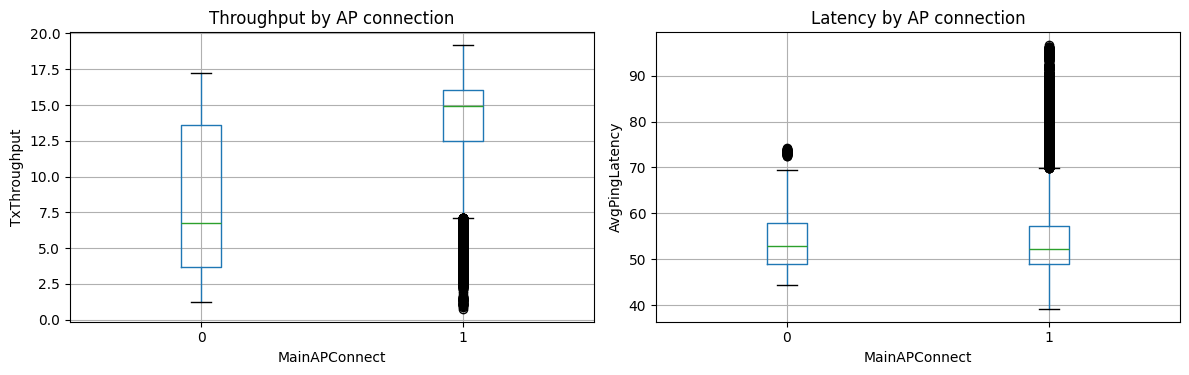

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df.boxplot(column="TxThroughput", by="MainAPConnect", ax=axes[0])
axes[0].set_title("Throughput by AP connection")
axes[0].set_xlabel("MainAPConnect")
axes[0].set_ylabel("TxThroughput")

train_df.boxplot(column="AvgPingLatency", by="MainAPConnect", ax=axes[1])
axes[1].set_title("Latency by AP connection")
axes[1].set_xlabel("MainAPConnect")
axes[1].set_ylabel("AvgPingLatency")

plt.suptitle("")
plt.tight_layout()
plt.show()

The AP connection type is useful especially for throughput. In the training data, samples connected to the main AP have an average throughput of about **13.4**, while samples connected to an extender are closer to **8.4**. For latency, the difference is much smaller, so latency seems to depend more on signal quality and location.

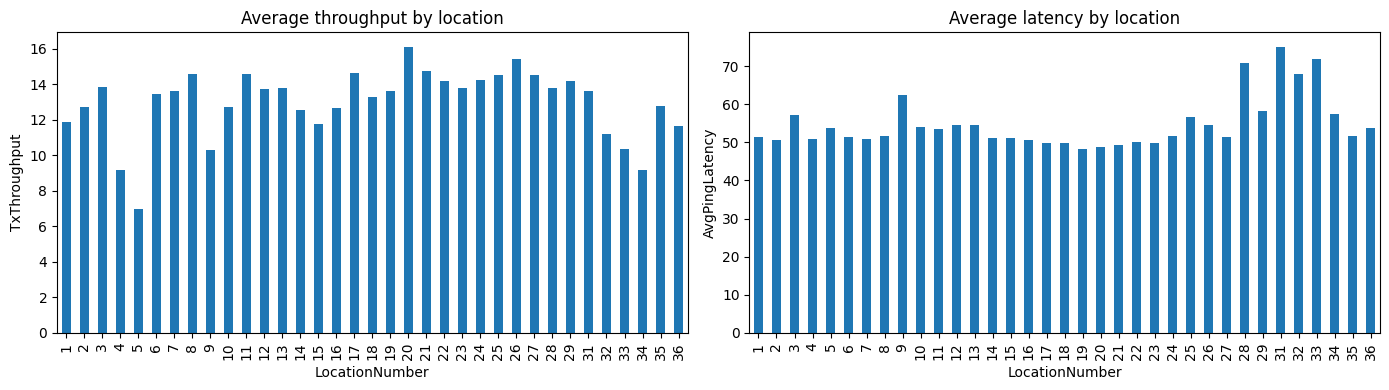

In [9]:
# Average performance by location.
location_stats = train_df.groupby("LocationNumber")[["TxThroughput", "AvgPingLatency", "RSSI"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

location_stats["TxThroughput"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average throughput by location")
axes[0].set_ylabel("TxThroughput")
axes[0].tick_params(axis="x", labelrotation=90)

location_stats["AvgPingLatency"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average latency by location")
axes[1].set_ylabel("AvgPingLatency")
axes[1].tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

The location also has a visible effect: some zones have clearly better average throughput or latency than others. I keep `LocationNumber`, but I encode it as categories because the number itself is only an identifier. For example, location 30 is not supposed to be “three times” location 10.

# Part II - FNN-based predictor

## 4. Feature selection and preparation

I keep all five features from the dataset:

- `LocationNumber`: represents the zone where the measurements were taken;
- `RSSI`: gives the received signal strength;
- `TxLinkSpeed` and `RxLinkSpeed`: represent the link speed in both directions;
- `MainAPConnect`: indicates if the client is connected to the main AP or to an extender.

For preprocessing:

- `LocationNumber` is transformed into dummy variables;
- `RSSI`, `TxLinkSpeed` and `RxLinkSpeed` are standardized;
- `MainAPConnect` is kept as 0/1;
- the two targets are also standardized during training, then converted back to their original scale for evaluation.

In [10]:
X = train_df[features]
y = train_df[targets]

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Dummy columns for the locations. I keep the same columns for train, validation and test.
location_columns = pd.get_dummies(train_df["LocationNumber"], prefix="loc").columns
numeric_features = ["RSSI", "TxLinkSpeed", "RxLinkSpeed"]

x_scaler = StandardScaler()
y_scaler = StandardScaler()


def prepare_features(df, fit_scaler=False):
    # One-hot encoding for the location.
    location_part = pd.get_dummies(df["LocationNumber"], prefix="loc")
    location_part = location_part.reindex(columns=location_columns, fill_value=0)

    # Scaling for the continuous variables.
    if fit_scaler:
        numeric_part = x_scaler.fit_transform(df[numeric_features])
    else:
        numeric_part = x_scaler.transform(df[numeric_features])

    # MainAPConnect is already binary, so I keep it unchanged.
    ap_part = df[["MainAPConnect"]].values

    return np.hstack([location_part.values, numeric_part, ap_part])


X_train = prepare_features(X_train_raw, fit_scaler=True)
X_val = prepare_features(X_val_raw)
X_test = prepare_features(test_df[features])

y_train = y_scaler.fit_transform(y_train_raw)
y_val = y_scaler.transform(y_val_raw)
y_test_true = test_df[targets].values

print("Input dimension after preprocessing:", X_train.shape[1])
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Input dimension after preprocessing: 39
Training samples: 26880
Validation samples: 6720
Test samples: 8400


## 5. FNN architecture

I use one multi-output FNN instead of two separate networks. The model has two output neurons: one for throughput and one for latency.

The architecture is intentionally simple:

- two hidden layers, enough for this small tabular dataset;
- ReLU activations in the hidden layers;
- a small dropout layer, just to limit overfitting a bit;
- MSE loss, because both outputs are continuous values;
- Adam optimizer, because it is a solid default choice for this kind of neural network.

I did not make the network too deep, because the dataset has only five original input variables. A very large model would probably be unnecessary and could overfit.

In [11]:
class WifiPerformanceFNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.layers(x)


model = WifiPerformanceFNN(input_dim=X_train.shape[1])
model

WifiPerformanceFNN(
  (layers): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=2, bias=True)
  )
)

## 6. Training

I train the model on 80% of the training file and keep 20% for validation. The validation loss is useful to check whether the network is learning without drifting too far from unseen data.

In [12]:
batch_size = 1024
epochs = 50
learning_rate = 1e-3

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32),
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = loss_function(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    train_loss = total_loss / len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = loss_function(val_predictions, y_val_tensor).item()
    val_losses.append(val_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train loss = {train_loss:.4f} | val loss = {val_loss:.4f}")

Epoch 001 | train loss = 0.9699 | val loss = 0.9406


Epoch 010 | train loss = 0.6044 | val loss = 0.6091


Epoch 020 | train loss = 0.5935 | val loss = 0.5958


Epoch 030 | train loss = 0.5806 | val loss = 0.5826


Epoch 040 | train loss = 0.5700 | val loss = 0.5681


Epoch 050 | train loss = 0.5599 | val loss = 0.5567


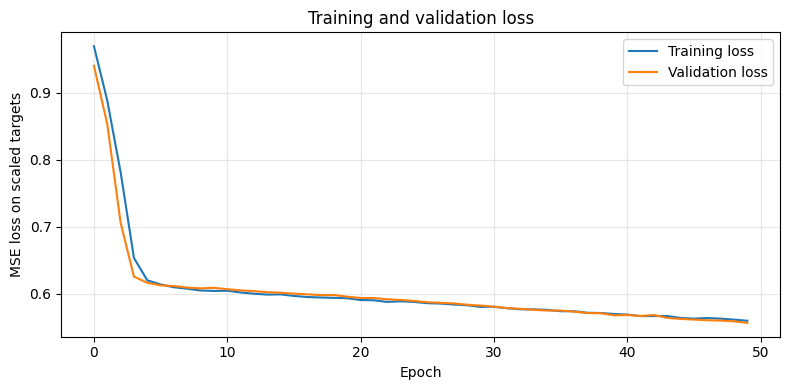

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Training loss")
ax.plot(val_losses, label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss on scaled targets")
ax.set_title("Training and validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The validation loss decreases together with the training loss. The two curves stay close during training, so the model is learning useful patterns without a strong sign of overfitting in this run.

## 7. Test evaluation

For the final evaluation, I convert the predictions back to the original units. This makes the errors easier to interpret.

I report three metrics:

- **MAE**: average absolute error;
- **RMSE**: similar to MAE but it penalizes large errors more;
- **R²**: proportion of the target variance explained by the model.

In [14]:
def predict_original_scale(model, X_array):
    model.eval()
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    with torch.no_grad():
        scaled_pred = model(X_tensor).numpy()
    return y_scaler.inverse_transform(scaled_pred)


def regression_metrics(y_true, y_pred, target_names):
    rows = []
    for i, target in enumerate(target_names):
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = mean_squared_error(y_true[:, i], y_pred[:, i]) ** 0.5
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        rows.append({"Target": target, "MAE": mae, "RMSE": rmse, "R2": r2})
    return pd.DataFrame(rows)


val_pred = predict_original_scale(model, X_val)
test_pred = predict_original_scale(model, X_test)

val_metrics = regression_metrics(y_val_raw.values, val_pred, targets)
test_metrics = regression_metrics(y_test_true, test_pred, targets)

print("Validation metrics")
display(val_metrics.round(3))

print("Test metrics")
display(test_metrics.round(3))

Validation metrics


,Target,MAE,RMSE,R2
0,TxThroughput,2.938,3.799,0.275
1,AvgPingLatency,3.788,5.299,0.634


Test metrics


,Target,MAE,RMSE,R2
0,TxThroughput,2.878,3.751,0.285
1,AvgPingLatency,3.834,5.390,0.620


In [15]:
# Mean baseline: it always predicts the average target value seen during training.
# The FNN should do better than this simple reference.
train_mean = y_train_raw.mean().values
baseline_pred = np.tile(train_mean, (len(test_df), 1))

baseline_metrics = regression_metrics(y_test_true, baseline_pred, targets)

comparison = pd.concat(
    [
        baseline_metrics.assign(Model="Mean baseline"),
        test_metrics.assign(Model="FNN"),
    ],
    ignore_index=True,
)

comparison = comparison[["Model", "Target", "MAE", "RMSE", "R2"]]
comparison.round(3)

,Model,Target,MAE,RMSE,R2
0,Mean baseline,TxThroughput,3.576,4.437,-0.000
1,Mean baseline,AvgPingLatency,6.400,8.746,-0.000
2,FNN,TxThroughput,2.878,3.751,0.285
3,FNN,AvgPingLatency,3.834,5.390,0.620


The FNN improves over the mean baseline on both targets.

For the test set, the FNN obtains about **2.88 MAE** for throughput and **3.83 MAE** for latency. The R² is around **0.29** for throughput and **0.62** for latency. So the model explains latency much better than throughput.

This is coherent with the data analysis: latency has clearer relations with signal strength, link speed and location. Throughput is improved too, but it remains harder because it probably depends on missing information such as channel load, interference, retransmissions or traffic variations.

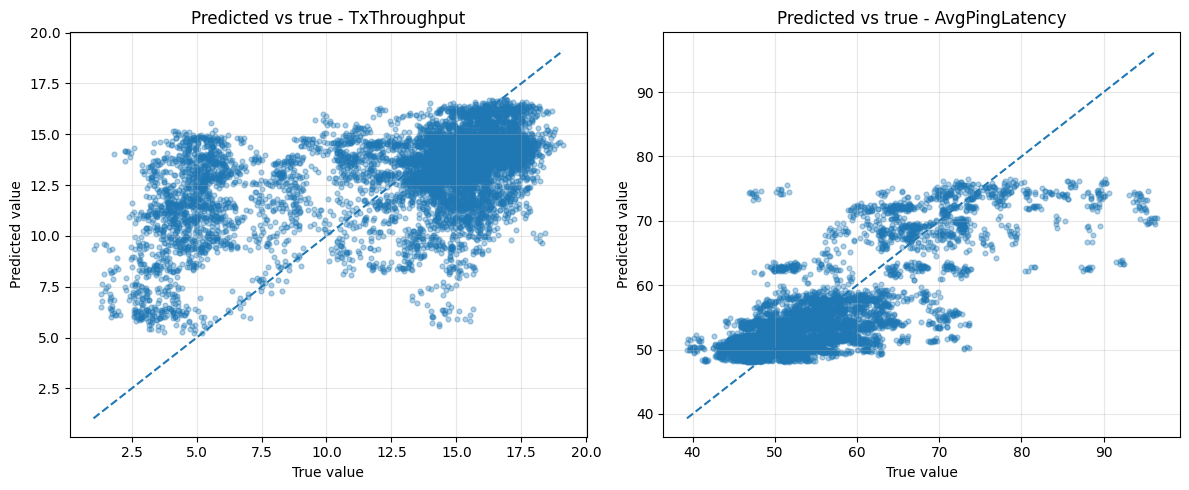

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target in enumerate(targets):
    axes[i].scatter(y_test_true[:, i], test_pred[:, i], alpha=0.35, s=12)
    min_value = min(y_test_true[:, i].min(), test_pred[:, i].min())
    max_value = max(y_test_true[:, i].max(), test_pred[:, i].max())
    axes[i].plot([min_value, max_value], [min_value, max_value], linestyle="--")
    axes[i].set_xlabel("True value")
    axes[i].set_ylabel("Predicted value")
    axes[i].set_title(f"Predicted vs true - {target}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

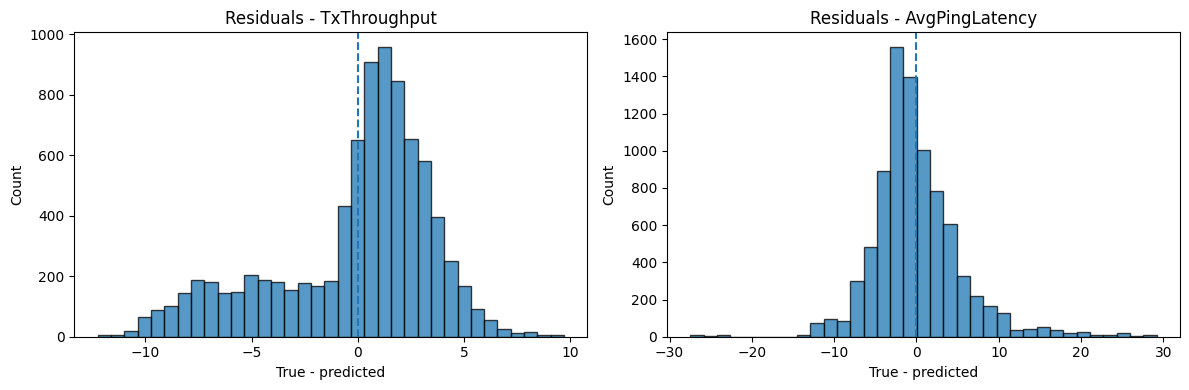

In [17]:
residuals = y_test_true - test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, target in enumerate(targets):
    axes[i].hist(residuals[:, i], bins=35, edgecolor="black", alpha=0.75)
    axes[i].axvline(0, linestyle="--")
    axes[i].set_title(f"Residuals - {target}")
    axes[i].set_xlabel("True - predicted")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

The prediction plots tell the same story as the metrics. For latency, the points follow the diagonal more clearly, so the predictions are closer to the real values. For throughput, the cloud is more scattered: the model gives a useful estimate, but many samples are still difficult to predict precisely from the available features only.

## 8. Final discussion

This seminar shows that a feedforward neural network can predict part of the Wi-Fi performance from the available measurements. The preprocessing step is important: `LocationNumber` is better treated as a categorical variable, and the continuous variables need to be standardized before training.

The model performs better for `AvgPingLatency` than for `TxThroughput`. This makes sense because latency is more directly linked to signal quality, link speed and location in this dataset. Throughput is more difficult because the dataset does not include all the variables that can affect it, such as channel load, interference, retransmissions or the behaviour of other devices.

Overall, the FNN is clearly better than a constant baseline, especially for latency. However, the results also show that the available features are not enough to perfectly model Wi-Fi performance. A stronger predictor would probably need more network-level information, for example channel occupancy, number of active users, packet retransmissions, or temporal traffic conditions.